In [1]:
import pyspoc
import pandas as pd
import numpy as np

from typing import Literal, Generator
from pathlib import Path

oct2py: failed to create default session: octave not found, please see README
Octave not available: octave not found, please see README
Starting JVM with java class D:\Projects\hcda\py-spoc\pyspoc/lib/jidt/infodynamics.jar.
Jpype JVM not available: No JVM shared library file (jvm.dll) found. Try setting up the JAVA_HOME environment variable properly.


Traceback (most recent call last):
  File "d:\Python-venvs\pyspoc-venv\Lib\site-packages\oct2py\__init__.py", line 55, in <module>
    octave = Oct2Py()
  File "d:\Python-venvs\pyspoc-venv\Lib\site-packages\oct2py\core.py", line 250, in __init__
    self.restart()
    ~~~~~~~~~~~~^^
  File "d:\Python-venvs\pyspoc-venv\Lib\site-packages\oct2py\core.py", line 1033, in restart
    raise Oct2PyError(str(e)) from None
oct2py.utils.Oct2PyError: octave not found, please see README


In [2]:
cfg = pyspoc.Config.from_yaml_file("testing", "cfg.yaml")

Registering YAML configuration file: cfg.yaml.
Building internal configuration.
  ✔ Module pyspoc.statistics.cov loaded successfully.
    ✔ Statistic Covariance scheme 'cov' added successfully.
    ✔ Statistic SpearmanR scheme 'sq' added successfully.
    ✔ Statistic SpearmanR scheme 'standard' added successfully.
    ✔ Statistic KendallTau scheme 'sq' added successfully.
    ✔ Statistic KendallTau scheme 'standard' added successfully.
  ✔ Module pyspoc.statistics.causal loaded successfully.
    (The following warnings were raised: ['Use shutil.which instead of find_executable', 'Detecting 1 CUDA device(s).', 'Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.'])
    ✔ Statistic InformationGeometricConditionalIndependence scheme 'standard' added successfully.
  ✔ Module pyspoc.statistics.distance loaded successfully.
    ✔ Statistic PairwiseDistance scheme 'standard' added successfully.
    ✔ St

In [3]:
def find_files(folder: str | Path, extension: str) -> list[Path]:
    folder = Path(folder)
    extension = extension.lstrip(".")
    return list(folder.rglob(f"*.{extension}"))

def get_file_registry(path: str | Path) -> pd.DataFrame:
    file_path = Path(path)

    if not file_path.exists():
        raise FileNotFoundError(f"Path {file_path} does not exist.")

    if not file_path.is_file():
        raise IsADirectoryError(f"Path {file_path} is not a file.")

    if not file_path.suffix != "csv":
        raise ValueError(f"Path {file_path} is not a CSV file.")

    return pd.read_csv(file_path, index_col="DatasetID")

In [4]:
base_data_path = Path("D:\\OneDrive\\OneDrive - Imperial College London\\Projects\\hcda\\data_gathering")
openml_format = ".parquet"
openml_path = base_data_path / "OpenML"
openml_files = find_files(openml_path, openml_format)
openml_registry_path = openml_path / "dataset_catalogue.csv"
openml_registry = get_file_registry(openml_registry_path)
result_index_list = list()
results = None
#n_files = len(openml_files)
n_files = 1
sample_shape = (10000,50)

In [5]:
for i in range(n_files):
    file = openml_files[i]

    if not file.name.startswith("X"):
        print(f"Skipping dataset {i+1}/{n_files} due to lack of design matrix.")
        continue

    file_name = file.name.rstrip(openml_format)
    dataset_id = int(file_name.split("_")[1])
    dataset_info = openml_registry.loc[dataset_id]
    dataset_name = dataset_info.Name
    dataset_modality = dataset_info.Modality
    dataset_domain = dataset_info.Domain
    data = pd.read_parquet(file)
    dataset = pyspoc.Dataset(data)
    
    print(f"Calculating stats for dataset {dataset_name} [{i+1}/{n_files}].")
    print("-" * 100)
    
    data_subsets = dataset.get_samples(
        sample_shape=sample_shape,
        sampling_type=["random","cyclical"],
        seed=0)

    n_subsets = len(data_subsets)
    
    for j, subset in enumerate(data_subsets):

        if n_subsets > 1:
            print()
            print(f"Processing subset {j+1}/{n_subsets}.")
            print("-" * 100)
        
        calc = pyspoc.Calculator(subset, name=dataset_name, normalise=True)
        calc.compute(cfg)
        result = calc.show_results("short")
        result_index_list.append((f"{dataset_name}_{j}", dataset_modality, dataset_domain))

        if results is None:
            results = result
        else:
            results = pd.concat((results, result))

    if i % 10 == 0 and results is not None:
        results.to_parquet("results4.parquet", engine="pyarrow")

if results is not None:
    results.to_parquet("results4.parquet", engine="pyarrow")

results

Calculating stats for dataset ECG5000 [1/1].
----------------------------------------------------------------------------------------------------
Normalising the dataset using StandardScaler 


Processing subset 1/3.
----------------------------------------------------------------------------------------------------
Normalising the dataset using StandardScaler 

----------------------------------------------------------------------------------------------------
Running calculation.
----------------------------------------------------------------------------------------------------


Computing Statistics [ECG5000: pyspoc.statistics.clustering.kmeans.statistics.KClusteringSimilarity.eleven-mahalanobis-rbf]: 100%|██████████| 16/16 [01:38<00:00,  6.15s/it]
Computing Reduction [ECG5000: pyspoc.statistics.clustering.kmeans.statistics.KClusteringSimilarity.eleven-mahalanobis-rbf=>pyspoc.rstatistics.norms.SchattenNorm.three]: 100%|██████████| 128/128 [00:00<00:00, 1180.49it/s]
Computing Reduced Statistics [ECG5000: pyspoc.rstatistics.dimreduce.orthopcae.rstatistics.OrthogonalPCAEVarianceExplainedRatio.three]: 100%|██████████| 4/4 [01:13<00:00, 18.30s/it]


----------------------------------------------------------------------------------------------------

Calculation complete. Time taken: 171.6444s
----------------------------------------------------------------------------------------------------

Processing subset 2/3.
----------------------------------------------------------------------------------------------------
Normalising the dataset using StandardScaler 

----------------------------------------------------------------------------------------------------
Running calculation.
----------------------------------------------------------------------------------------------------


Computing Statistics [ECG5000: pyspoc.statistics.clustering.kmeans.statistics.KClusteringSimilarity.eleven-mahalanobis-rbf]: 100%|██████████| 16/16 [01:31<00:00,  5.75s/it]
Computing Reduction [ECG5000: pyspoc.statistics.clustering.kmeans.statistics.KClusteringSimilarity.eleven-mahalanobis-rbf=>pyspoc.rstatistics.norms.SchattenNorm.three]: 100%|██████████| 128/128 [00:00<00:00, 1051.31it/s]
Computing Reduced Statistics [ECG5000: pyspoc.rstatistics.dimreduce.orthopcae.rstatistics.OrthogonalPCAEVarianceExplainedRatio.three]: 100%|██████████| 4/4 [01:12<00:00, 18.02s/it]


----------------------------------------------------------------------------------------------------

Calculation complete. Time taken: 164.1242s
----------------------------------------------------------------------------------------------------

Processing subset 3/3.
----------------------------------------------------------------------------------------------------
Normalising the dataset using StandardScaler 

----------------------------------------------------------------------------------------------------
Running calculation.
----------------------------------------------------------------------------------------------------


Computing Statistics [ECG5000: pyspoc.statistics.clustering.kmeans.statistics.KClusteringSimilarity.eleven-mahalanobis-rbf]: 100%|██████████| 16/16 [01:37<00:00,  6.07s/it]
Computing Reduction [ECG5000: pyspoc.statistics.clustering.kmeans.statistics.KClusteringSimilarity.eleven-mahalanobis-rbf=>pyspoc.rstatistics.norms.SchattenNorm.three]: 100%|██████████| 128/128 [00:00<00:00, 1117.32it/s]
Computing Reduced Statistics [ECG5000: pyspoc.rstatistics.dimreduce.orthopcae.rstatistics.OrthogonalPCAEVarianceExplainedRatio.three]: 100%|██████████| 4/4 [01:13<00:00, 18.43s/it]

----------------------------------------------------------------------------------------------------

Calculation complete. Time taken: 170.8939s
----------------------------------------------------------------------------------------------------


Statistic     cov.cov                                            \
Reducer   svd.three_1 svd.three_2 svd.three_3 det-scaled.scaled   
0           29.530214    8.086510    4.512371      7.427237e-34   
0           20.318568   13.769231    6.737075      5.339436e-25   
0           20.543918    9.858926    6.706083      1.363509e-34   

Statistic                                                                  \
Reducer   det.non-scaled erank.standard stable-rank.standard sch-norm.one   
0           5.516384e-67       4.334255             1.113016         50.0   
0           2.850958e-49       6.125254             1.595546         50.0   
0           1.859156e-68       6.546831             1.403241         50.0   

Statistic                              ... kmeans-cs.eleven-mahalanobis-rbf  \
Reducer   sch-norm.two sch-norm.three  ...                     sch-norm.two   
0            31.154250      29.777640  ...                         8.499698   
0            25.665382      22.457999  ...                         9.149041   
0            24.336014      21.557026  ...                         8.209859   

Statistic                 rge.zero   rge.one pca-var.three            \
Reducer   sch-norm.three                                 1         2   
0               8.418082  0.000133  0.000180      0.590604  0.161730   
0               9.095847  0.000121  0.000180      0.406371  0.275385   
0               8.140868  0.000073  0.000082      0.410878  0.197179   

Statistic           opcae-var.three                 
Reducer           3               1    2         3  
0          0.090247             0.0  0.0  0.000000  
0          0.134741             0.0  0.0  0.081331  
0          0.134122             0.0  0.0  0.000000  

[3 rows x 168 columns]

In [ ]:
# Load up results
results = pd.read_parquet("results3.parquet", engine="pyarrow")

In [390]:
results.head(10)

Statistic                                             Covariance             \
Reducer                                                    SVD_1      SVD_2   
Dataset           Modality    Domain                                          
ECG5000           Time-Series Bio                      16.273010  10.353959   
scm1d             Time-Series Industrial               13.532811   7.553227   
year              Tabular     Benchmarking/Artificial   6.357075   4.253714   
Epsilon           Tabular     Benchmarking/Artificial  14.937458   1.630837   
colon             Tabular     Benchmarking/Artificial  37.501889   1.939934   
bates_regr_100    Tabular     Benchmarking/Artificial   1.137570   1.122190   
bates_classif_100 Tabular     Benchmarking/Artificial   1.133825   1.122063   
yeast_ml8         Unknown     Bio                       5.952169   3.878398   
mtp               Unknown     Bio                      16.076698   6.754131   
Bioresponse       Tabular     Bio                      10.870344   4.251470   

Statistic                                                                      \
Reducer                                                   SVD_3    Det-Scaled   
Dataset           Modality    Domain                                            
ECG5000           Time-Series Bio                      7.084693  2.492221e-23   
scm1d             Time-Series Industrial               5.027749  5.989388e-16   
year              Tabular     Benchmarking/Artificial  3.369303  1.100117e-04   
Epsilon           Tabular     Benchmarking/Artificial  1.199540  1.128652e-05   
colon             Tabular     Benchmarking/Artificial  1.535955  1.090250e-21   
bates_regr_100    Tabular     Benchmarking/Artificial  1.113499  9.399232e-01   
bates_classif_100 Tabular     Benchmarking/Artificial  1.113598  9.395313e-01   
yeast_ml8         Unknown     Bio                      3.432595  3.339289e-05   
mtp               Unknown     Bio                      3.824527  8.405765e-23   
Bioresponse       Tabular     Bio                      3.274670  1.308742e-07   

Statistic                                                            \
Reducer                                                         Det   
Dataset           Modality    Domain                                  
ECG5000           Time-Series Bio                      9.224167e-46   
scm1d             Time-Series Industrial               6.612123e-31   
year              Tabular     Benchmarking/Artificial  2.173342e-08   
Epsilon           Tabular     Benchmarking/Artificial  3.799742e-10   
colon             Tabular     Benchmarking/Artificial  1.343241e-42   
bates_regr_100    Tabular     Benchmarking/Artificial  8.834643e-01   
bates_classif_100 Tabular     Benchmarking/Artificial  8.827237e-01   
yeast_ml8         Unknown     Bio                      1.821178e-09   
mtp               Unknown     Bio                      1.430827e-44   
Bioresponse       Tabular     Bio                      4.910681e-14   

Statistic                                                            \
Reducer                                               EffectiveRank   
Dataset           Modality    Domain                                  
ECG5000           Time-Series Bio                          9.000146   
scm1d             Time-Series Industrial                  14.240683   
year              Tabular     Benchmarking/Artificial     33.612971   
Epsilon           Tabular     Benchmarking/Artificial     25.351017   
colon             Tabular     Benchmarking/Artificial      3.844091   
bates_regr_100    Tabular     Benchmarking/Artificial     49.876453   
bates_classif_100 Tabular     Benchmarking/Artificial     49.875757   
yeast_ml8         Unknown     Bio                         32.444041   
mtp               Unknown     Bio                         13.666419   
Bioresponse       Tabular     Bio                         24.796257   

Statistic                                                         \
Re

In [ ]:
# Remove zero standard deviation columns.
results = results.loc[:, ~np.isclose(results.std(axis=0), 0)]

In [ ]:
# Impute row-weighted column means for missing values.
row_means = results.mean(axis=1).values
row_weights = row_means / row_means.sum()

for col in results.columns:
    col_srs = results[col]
    col_vals = col_srs.values
    nan_mask = np.isnan(col_vals)
    has_nan = np.any(nan_mask)

    if has_nan:
        col_mean = col_srs.mean()
        means = row_weights[nan_mask] * col_mean
        results.loc[nan_mask, col] = means

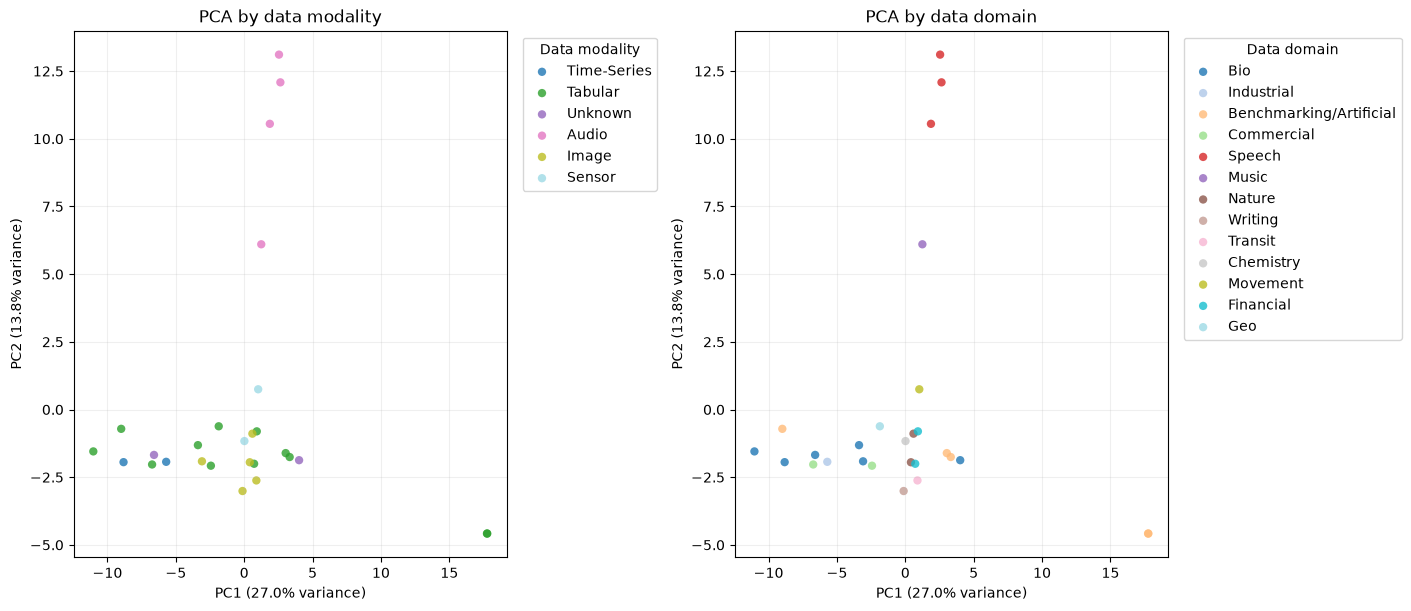

In [ ]:
import plotting as p

fig, axs, pcs = p.plot_pca(results)

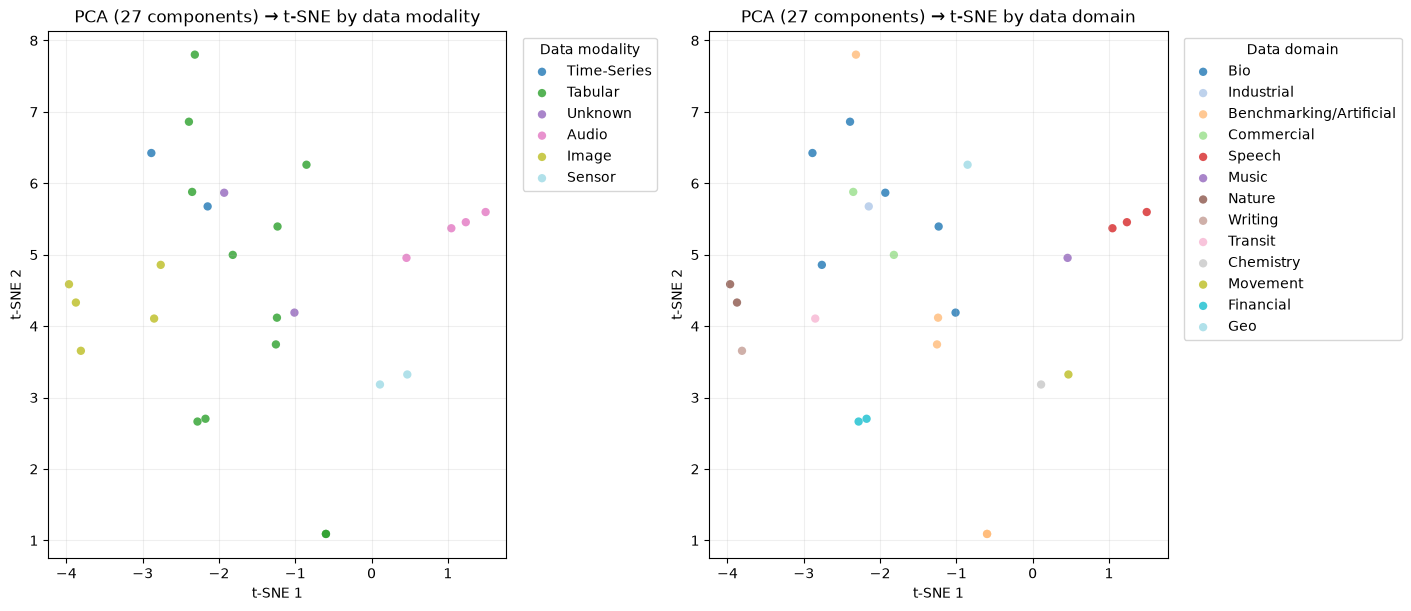

In [ ]:
fig, axs, tsnes = p.plot_pca_tsne(results, perplexity=15)

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


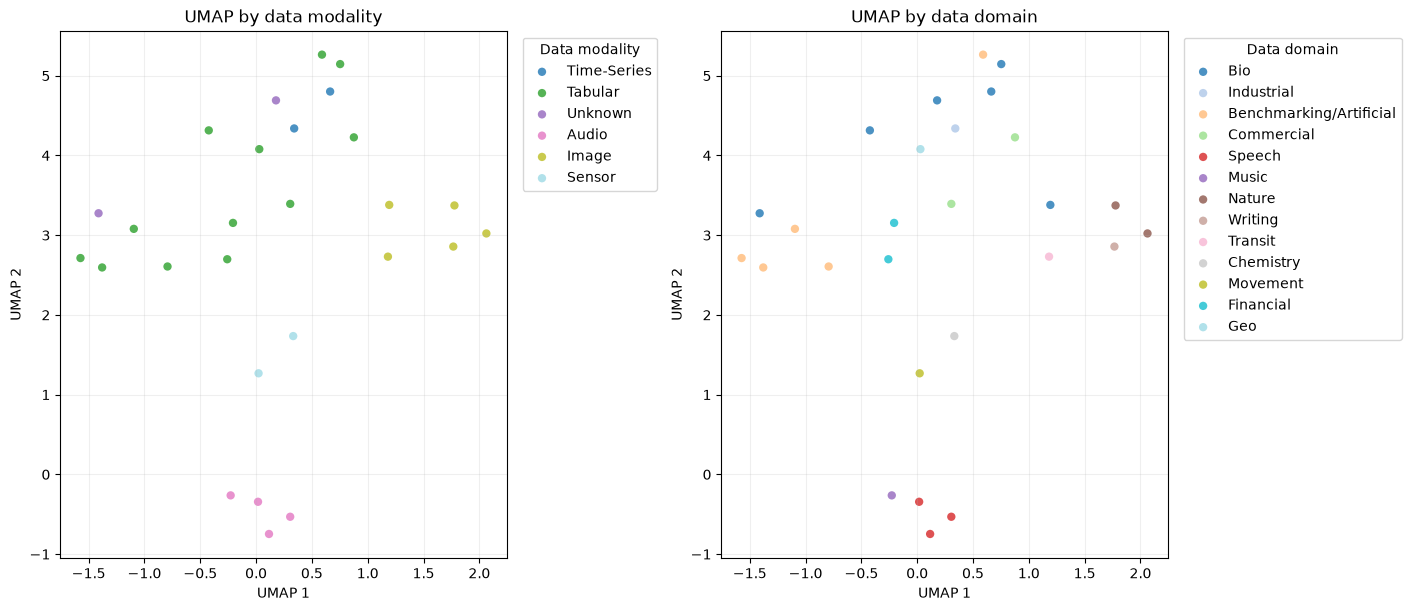

In [ ]:
fig, axs, umaps = p.plot_umap(results, min_dist=0.1, n_neighbors=5, random_seed=4)

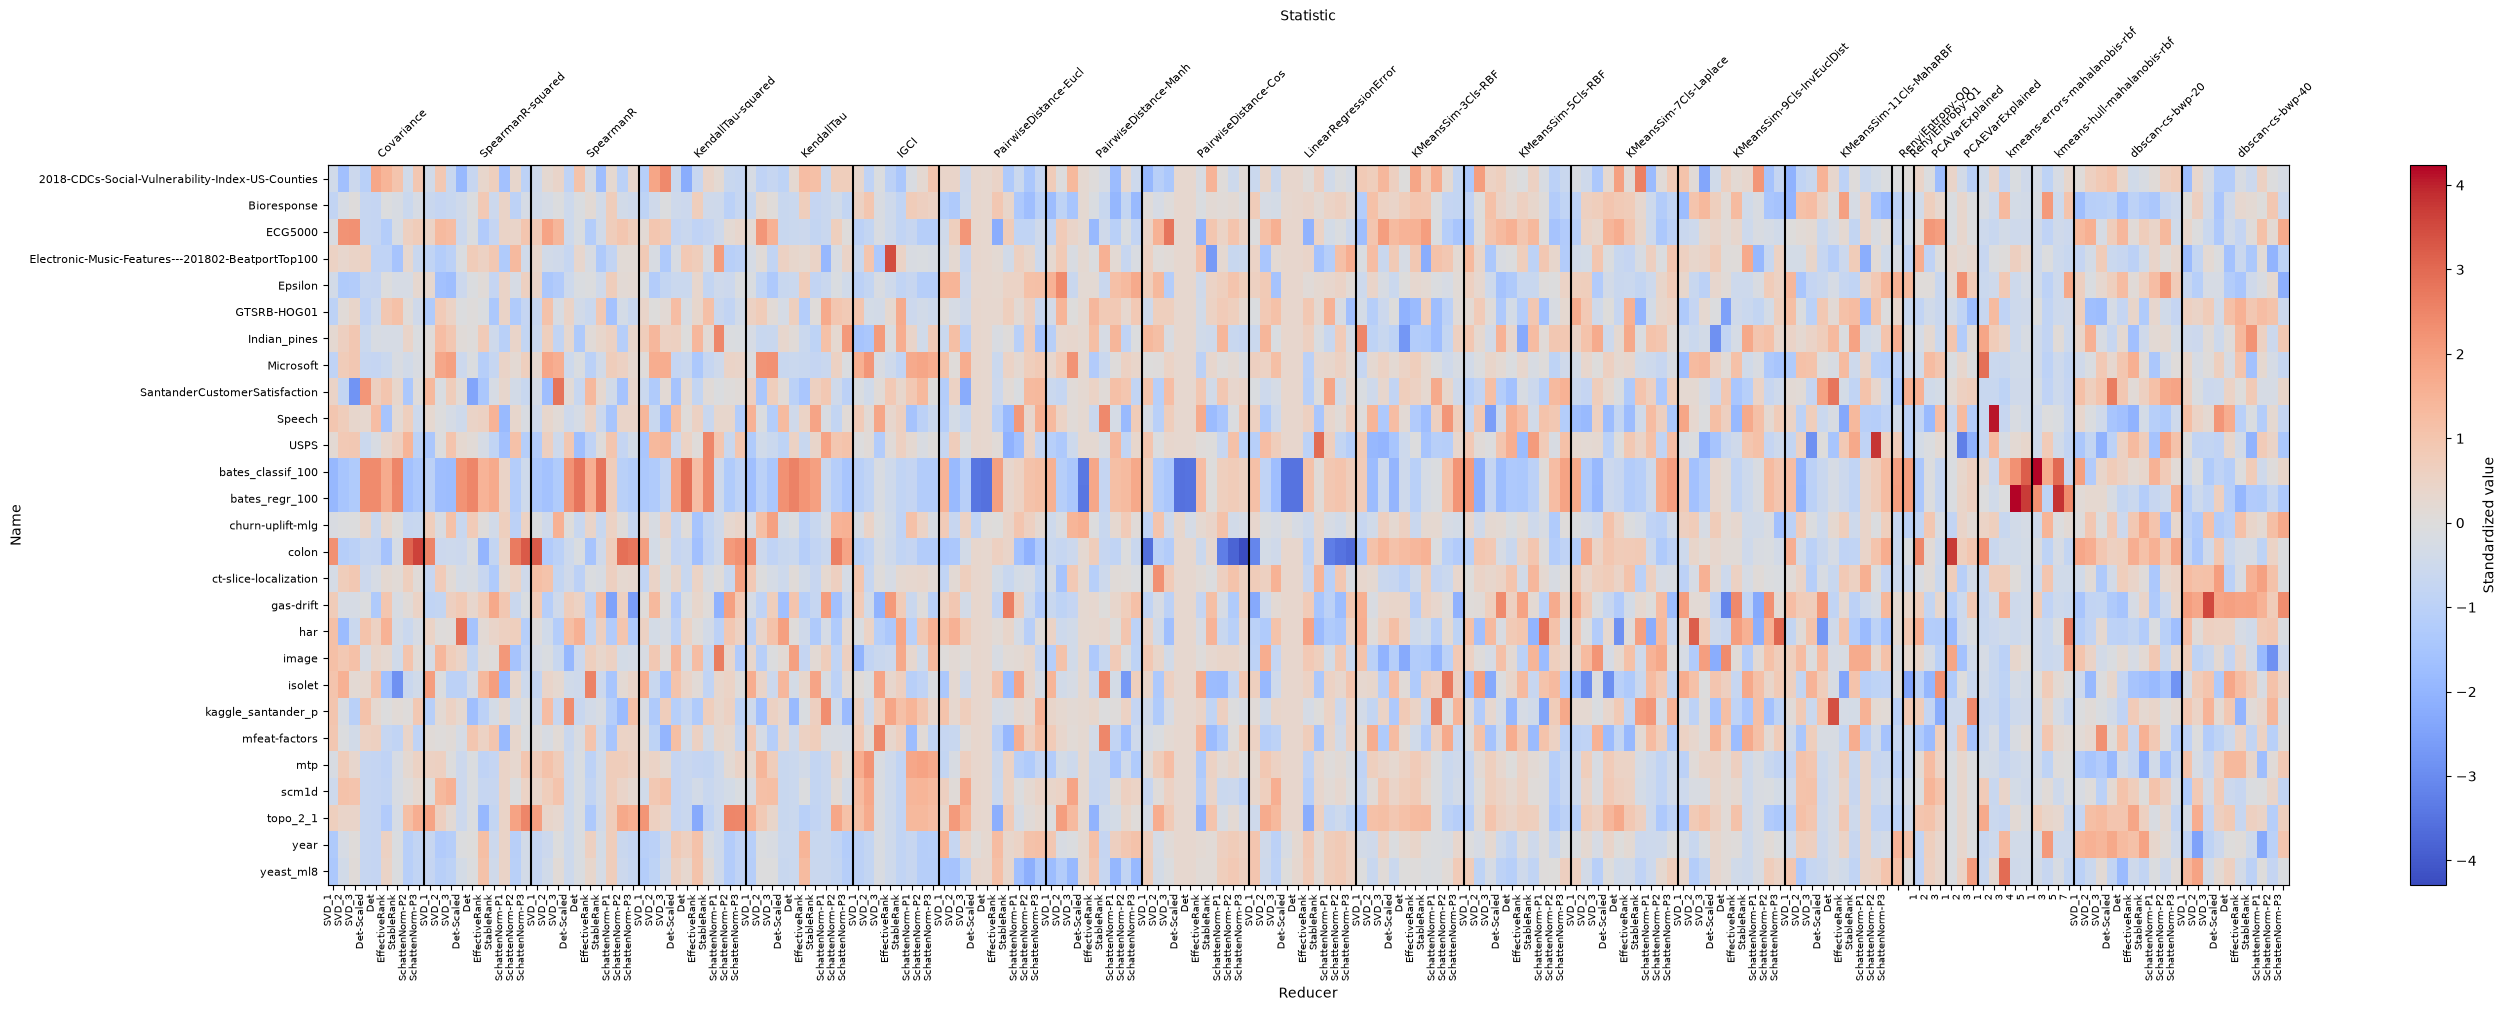

In [388]:
fig, axs, hmap = p.plot_heatmap(results, cmap="coolwarm", add_horiz_dividers=False, figsize=(25,10))